In [1]:
import pandas as pd

# -----------------------------
# 1. Read dataset using relative path
# -----------------------------
DATA_PATH = "../data/processed/canada_crop_yield.csv"

print(" Loading dataset...")
df = pd.read_csv(DATA_PATH)

# -----------------------------
# 2. Basic structure checks
# -----------------------------
print("\n Dataset Preview:")
display(df.head())

print("\n Shape of dataset:")
print(df.shape)

print("\n Column names:")
print(df.columns.tolist())

# -----------------------------
# 3. Clean column names (optional but recommended)
# -----------------------------
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print("\n Cleaned column names:")
print(df.columns.tolist())

# -----------------------------
# 4. Check missing values
# -----------------------------
print("\n Missing values per column:")
print(df.isna().sum())

# -----------------------------
# 5. Basic descriptive statistics
# -----------------------------
print("\n Summary statistics:")
display(df.describe())

# -----------------------------
# 6. Unique crops available
# -----------------------------
print("\n Unique crop types:")
print(df["crop"].unique())


 Loading dataset...

 Dataset Preview:


,country,year,crop,yield_hg_ha
0,Canada,2001,"anise,_badian,_fennel,_coriander",3279.0
1,Canada,2002,"anise,_badian,_fennel,_coriander",5672.0
2,Canada,2003,"anise,_badian,_fennel,_coriander",5634.0
3,Canada,2004,"anise,_badian,_fennel,_coriander",7376.0
4,Canada,2005,"anise,_badian,_fennel,_coriander",9570.0



 Shape of dataset:
(3603, 4)

 Column names:
['country', 'year', 'crop', 'yield_hg_ha']

 Cleaned column names:
['country', 'year', 'crop', 'yield_hg_ha']

 Missing values per column:
country        0
year           0
crop           0
yield_hg_ha    0
dtype: int64

 Summary statistics:


,year,yield_hg_ha
count,3603.000000,3603.000000
mean,1991.215931,101661.477102
std,16.919281,127151.544686
min,1961.000000,659.000000
25%,1977.000000,17939.000000
50%,1992.000000,47822.000000
75%,2006.000000,128069.500000
max,2019.000000,846532.000000



 Unique crop types:
['anise,_badian,_fennel,_coriander' 'apples' 'apricots' 'asparagus'
 'barley' 'beans,_dry' 'beans,_green' 'blueberries'
 'broad_beans,_horse_beans,_dry' 'buckwheat'
 'cabbages_and_other_brassicas' 'canary_seed' 'carrots_and_turnips'
 'cauliflowers_and_broccoli' 'cherries' 'cherries,_sour' 'chick_peas'
 'chillies_and_peppers,_green' 'cranberries' 'cucumbers_and_gherkins'
 'fibre_crops_nes' 'garlic' 'grain,_mixed' 'grapes' 'hops' 'kiwi_fruit'
 'leeks,_other_alliaceous_vegetables' 'lentils' 'lettuce_and_chicory'
 'linseed' 'maize' 'maize,_green' 'melons,_other_(inc.cantaloupes)'
 'mustard_seed' 'oats' 'oilseeds_nes' 'onions,_dry'
 'peaches_and_nectarines' 'pears' 'peas,_dry' 'peas,_green'
 'plums_and_sloes' 'potatoes' 'pumpkins,_squash_and_gourds' 'rapeseed'
 'raspberries' 'rye' 'safflower_seed' 'soybeans' 'spinach' 'strawberries'
 'sugar_beet' 'sunflower_seed' 'tobacco,_unmanufactured' 'tomatoes'
 'triticale' 'vegetables,_fresh_nes' 'watermelons' 'wheat'
 'cereals,_t

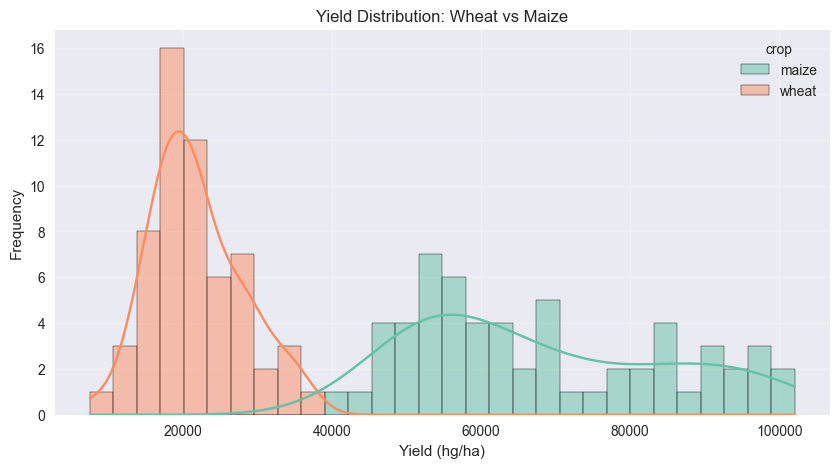

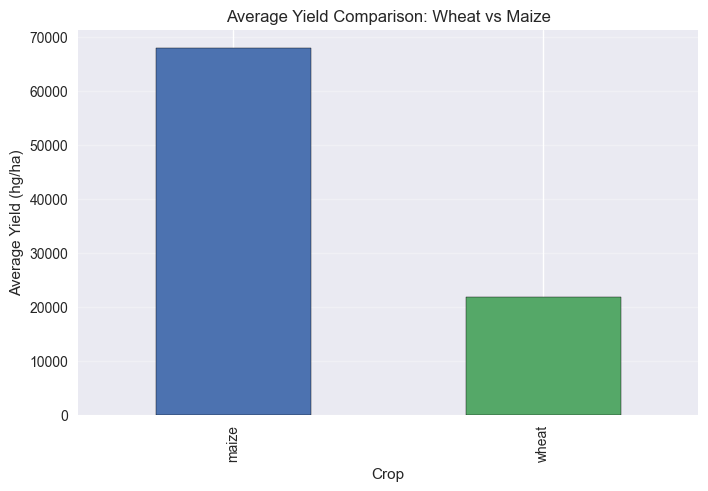

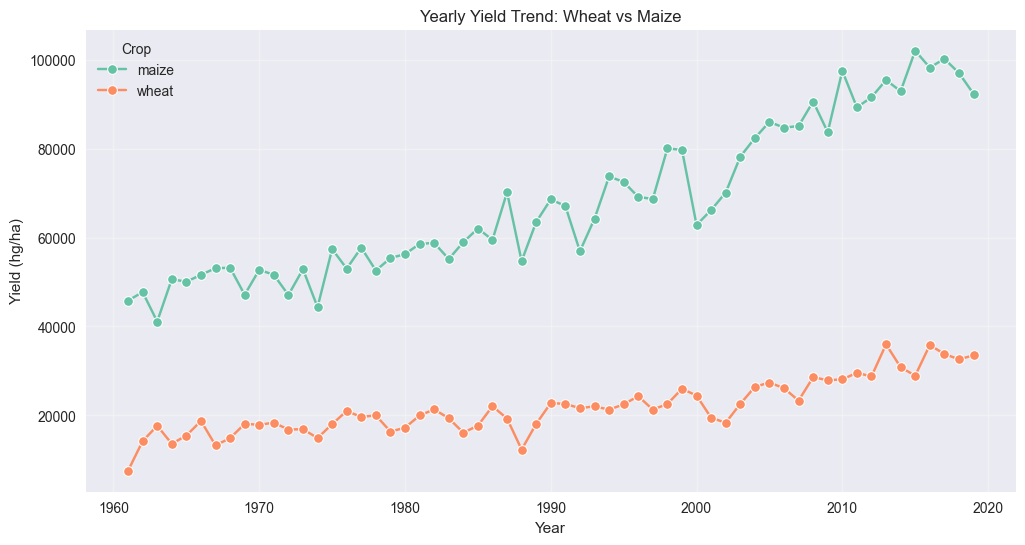

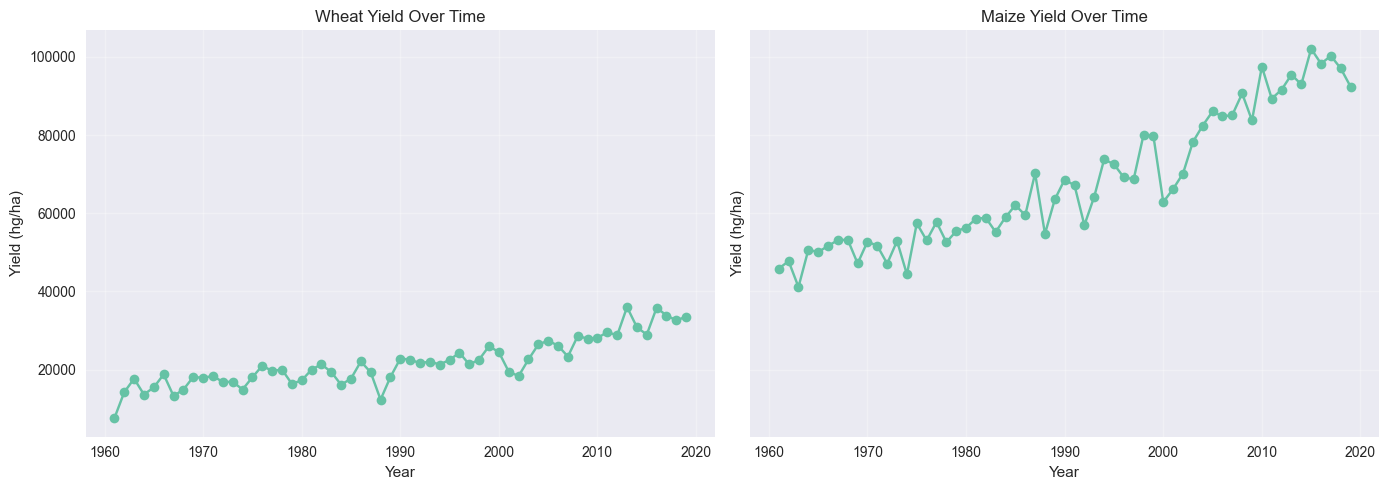

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter dataset for only wheat and maize
selected_crops = ["wheat", "maize"]
df_filtered = df[df["crop"].isin(selected_crops)]

# Apply clean style
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

# -----------------------------
# 1. Histogram for wheat + maize
# -----------------------------
plt.figure(figsize=(10, 5))
sns.histplot(data=df_filtered, x="yield_hg_ha", hue="crop", bins=30, kde=True)
plt.title("Yield Distribution: Wheat vs Maize")
plt.xlabel("Yield (hg/ha)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# 2. Bar chart: Average yield (wheat vs maize)
# -----------------------------
avg_yield = df_filtered.groupby("crop")["yield_hg_ha"].mean()

plt.figure(figsize=(8, 5))
avg_yield.plot(kind="bar", color=["#4C72B0", "#55A868"], edgecolor="black")
plt.title("Average Yield Comparison: Wheat vs Maize")
plt.ylabel("Average Yield (hg/ha)")
plt.xlabel("Crop")
plt.grid(axis="y", alpha=0.3)
plt.show()

# -----------------------------
# 3. Yearly trend comparison
# -----------------------------
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_filtered, x="year", y="yield_hg_ha", hue="crop", marker="o")
plt.title("Yearly Yield Trend: Wheat vs Maize")
plt.xlabel("Year")
plt.ylabel("Yield (hg/ha)")
plt.grid(True, alpha=0.3)
plt.legend(title="Crop")
plt.show()

# -----------------------------
# 4. Optional: Separate plots for each crop
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, crop in zip(axes, selected_crops):
    temp = df_filtered[df_filtered["crop"] == crop]
    ax.plot(temp["year"], temp["yield_hg_ha"], marker="o")
    ax.set_title(f"{crop.capitalize()} Yield Over Time")
    ax.set_xlabel("Year")
    ax.set_ylabel("Yield (hg/ha)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
